<a href="https://colab.research.google.com/github/Kiranmai-Guddanti/BEE-102-Spring-2025-Assignment/blob/main/05_VPlot.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Problem Statement**

You can imagine when a protein binds to DNA, then that region will be protected by nucleases (a type of enzyme that cleaves DNA). If you are to plot the protected fragments at protein binding sites, it will take a V-form. Your goal is to show this V-formation using the input data.

data

**Example lines from the above file:**

        2	chr1	90919	91937	chr1:91382-91550|carroll_ctcf_mcf7_v45m`2_GTGGCACCAGGTGGCAGCA	16.2951	+	chr1	90838	91006	IH02_00.pairs@15152	168	+
        2	chr1	90919	91937	chr1:91382-91550|carroll_ctcf_mcf7_v45m`2_GTGGCACCAGGTGGCAGCA	16.2951	+	chr1	90846	90998	IH02_04.pairs@4163	152	+
        2	chr1	90919	91937	chr1:91382-91550|carroll_ctcf_mcf7_v45m`2_GTGGCACCAGGTGGCAGCA	16.2951	+	chr1	90851	91000	IH02_04.pairs@4164	149	+
        
From every line of this file, you have to derive three values:

X: Difference between two centers. C1 = center using Column3 and Column4, C2 = center using Column9 and Column10. X-coordinate will be C2 - C1

Y: Column10 - Column9

Z: Counter of Y at X. By default Z for Y at X is Zero.

And example is:

-500 65 10

X: -500, Y: 65, and Z: 10, telling that 500 bases relative to protein bound to DNA has 10 fragments of 65 base pair in size.

You have to plot a heatmap of this.

# **Approach**

---

### **Goal of the Task**

The objective is to **visualize a characteristic V-shaped pattern** formed by DNA fragments around protein binding sites. When proteins bind to DNA, they protect nearby regions from being cut by nucleases. As a result, DNA fragments mapped near these sites tend to have specific patterns of length and positioning. This protection effect often forms a “V” pattern when plotting:

- **X-axis (X):** The **position** of a DNA fragment **relative to the protein binding site**.
- **Y-axis (Y):** The **length** of the DNA fragment.
- **Z-axis (Z):** The **number of fragments** of a certain length at that specific relative position.

We use a **heatmap** to represent these values — with X and Y as coordinates and Z as the color intensity.

\


### **Input Data Format**

Each line in the input `.gz` file represents a DNA fragment mapped to the genome. The important fields are:

- **Columns 3 and 4:** Start and end of the protein-bound region.
- **Columns 9 and 10:** Start and end of the mapped fragment.

We extract meaningful biological signals from these raw coordinates.

\


###  **Step-by-Step Explanation of the Solution**

1. **Reading the Compressed File**  
   Instead of extracting the `.gz` file, we read it directly using Python’s `gzip` module. This keeps the workflow memory-efficient and cleaner.

2. **Parsing Required Fields**  
   For each line in the file:
   - We extract the **center of the protein binding region** by averaging the start and end positions.
   - We do the same for the **fragment**.
   - The difference between fragment center and protein center gives us the **relative position (X)**.
   - The fragment's end minus start gives us its **length (Y)**.

3. **Counting Occurrences (Z)**  
   We maintain a counter for each `(X, Y)` pair — this tells us how many fragments of a given length occur at a certain offset from the binding site.

4. **Preparing for Heatmap Plotting**  
   Once all data is read:
   - We extract all unique X and Y values, and sort them.
   - A 2D matrix is initialized where each row represents a fragment length (Y) and each column represents a position relative to the protein (X).
   - Each cell in the matrix is filled with the corresponding count (Z).

5. **Visualizing the Heatmap**  
   We use `seaborn.heatmap()` to plot the matrix:
   - The **color intensity** shows how frequently certain fragment lengths appear at particular relative positions.
   - The Y-axis is **inverted** to match common biological plotting conventions (short fragments appear on top).
   - Ticks are adjusted for readability.



In [ ]:
import gzip
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict

# Compressed input file
file_path = "mapped.bed.gz"

# Count occurrences of (X, Y)
count_map = defaultdict(int)

# Open and read compressed file
with gzip.open(file_path, 'rt') as file:
    for line in file:
        fields = line.strip().split('\t')

        # Center of protein-bound region (col 3 & 4)
        center_protein = (int(fields[2]) + int(fields[3])) // 2

        # Center of fragment (col 9 & 10)
        center_fragment = (int(fields[8]) + int(fields[9])) // 2

        # X = offset from protein binding center
        x = center_fragment - center_protein

        # Y = fragment length
        y = int(fields[9]) - int(fields[8])

        # Count the (X, Y) occurrence
        count_map[(x, y)] += 1

print("Total unique (X, Y) pairs:", len(count_map))




Total unique (X, Y) pairs: 280752


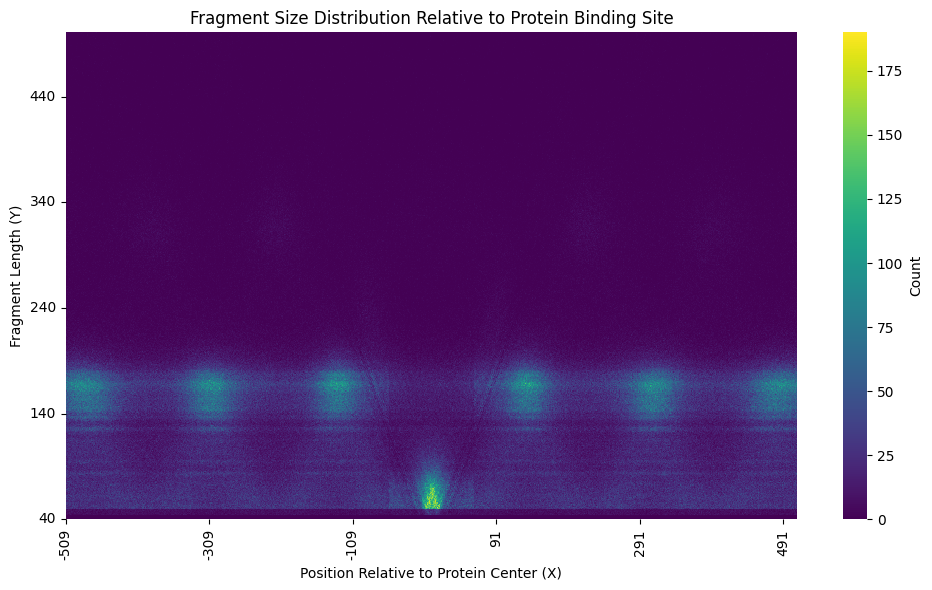

In [ ]:
# Create sorted unique lists of X and Y
x_vals = sorted({x for x, _ in count_map})
y_vals = sorted({y for _, y in count_map})

# Index maps for matrix placement
x_index = {x: i for i, x in enumerate(x_vals)}
y_index = {y: i for i, y in enumerate(y_vals)}

# Create heatmap matrix
heatmap = np.zeros((len(y_vals), len(x_vals)))
for (x, y), count in count_map.items():
    heatmap[y_index[y], x_index[x]] = count

# Plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(heatmap, cmap="viridis", cbar_kws={'label': 'Count'})
plt.gca().invert_yaxis()
plt.xticks(np.arange(len(x_vals))[::200], x_vals[::200])
plt.yticks(np.arange(len(y_vals))[::100], y_vals[::100])
plt.title("Fragment Size Distribution Relative to Protein Binding Site")
plt.xlabel("Position Relative to Protein Center (X)")
plt.ylabel("Fragment Length (Y)")
plt.tight_layout()
plt.show()